# Evaluación cuantitativa de algoritmos de cambio semánticos

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

In [3]:
# Umbrales cables
umbral_top = 0 # antes 5 se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
umbral_frec_menos = 2 # < antes 5 mediana de frecuencia de ocurrencia de palabra en titulos 
umbral_frec_menos_full  = 5 # antes 9 < amedia de ocurrencia de palabra en periodo de 5 años
topn_vecinos = 100

# Config modelo https://radimrehurek.com/gensim/models/word2vec.html
tam_vector = 100 # Dimensionalidad de los vectores de palabras.
ventana = 8 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
iteracion = 50

In [4]:
all_dfs = {}

df_names = [
    'procrustes', 
    'NN'
]

basenames = [
    'estabilidad_procrustes',
    'estabilidad_NN'
]

descriptions = [
    'Procrustes ortogonal',
    'k vecinos más cercanos'
]

flag = [
    True,
    False

]

In [5]:
# Unificamos archivos
for (i, (df_name, basename, description,f)) in enumerate(zip(df_names, basenames, descriptions,flag)):
    filename = modelo_dir+'/'+basename+'/'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv'
    print('Leyendo', filename, end='...')
    df = pd.read_csv(filename)
    all_dfs[df_name] = {
        'df': df,
        'descripcion': description,
        'bandera': f
    }
    print('archivos:', df.shape)

Leyendo C:/Users/Usuario/iamas_iniciativasleg_salud/src/data//archivos_out/modelos_swmwosge_1008211100/estabilidad_procrustes/estabilidad_procrustes_iter50_tam100.csv...archivos: (54700, 7)
Leyendo C:/Users/Usuario/iamas_iniciativasleg_salud/src/data//archivos_out/modelos_swmwosge_1008211100/estabilidad_NN/estabilidad_NN_iter50_tam100.csv...archivos: (65250, 7)


In [6]:
# Normalizar nombres
all_dfs['procrustes']['df'].rename(
    columns={
        'top10_vecindad_t1': 'neighbors_t1', 
        'top10_vecindad_t2':'neighbors_t2'},
    inplace=True)
all_dfs['procrustes']['df'].head(1)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,neighbors_t1,neighbors_t2
0,17,"(2014, 2019)",accion,0.16248,461,"[('comunitario', 0.6701722741127014), ('julio', 0.6596931219100952), ('judicial', 0.648351788520813), ('nacimiento', 0.6341621279716492), ('valor', 0.6208097338676453), ('doctor', 0.6187101602554321), ('psicologico', 0.5932990312576294), ('premio', 0.5850068926811218), ('mental', 0.5469589233398438), ('listado', 0.5299479961395264)]","[('celula', 0.6882323622703552), ('epidemiologico', 0.6513953804969788), ('organo', 0.6446195840835571), ('promover', 0.6213864088058472), ('recoleccion', 0.5605630278587341), ('padecer', 0.5597422122955322), ('proteina', 0.558529794216156), ('aplv', 0.5509136319160461), ('artriti', 0.5387381911277771), ('donacion', 0.5236662030220032)]"


In [ ]:
#print(all_dfs['procrustes']['df']['par_periodo'].unique())

In [7]:
# Normalizar
all_dfs['NN']['df'].rename(
    columns={
        'topn_vecindad_t1': 'neighbors_t1', 
        'topn_vecindad_t2': 'neighbors_t2'},
    inplace=True)
all_dfs['NN']['df'].head(1)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,neighbors_t1,neighbors_t2
0,49,"(2014, 2019)",comunitario,0,0,"['marzo', 'prestacion', 'regulatorio', 'marco', 'calidad', 'desarrollo', 'mes', 'mental', 'instituto', 'violencia', 'medicina', 'prepagar', 'red']","['comedor', 'agente', 'escolar', 'asignacion', 'reanimacion', 'capacitacion']"


In [ ]:
#print(all_dfs['NN']['df']['par_periodo'].unique())

Aplicamos la comparación a la tarea de detección de cambios en el uso de palabras primero para los pareas 2009-2013 y 2014-2018 y luego, para 2014-2018 y 2019-2023. 
Utilizamos la intersección @k, propuesta por Gonen et al., que mide el porcentaje de palabras compartidas en las k palabras más cambiadas durante varios reinicios, cambiando cada vez la semilla aleatoria.

 Para cada enfoque (p. ej., procrustes) y entre los dos períodos, medimos el cambio en el uso de palabras y detectamos las palabras más cambiadas. Al repetir la medición con diferentes semillas aleatorias (50 iteraciones), calculamos las palabras comunes cambiadas en las repeticiones. Específicamente, ejecutamos cada enfoque de cambio de uso y recopilamos las k palabras más cambiadas, donde k ∈ k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800,850,900,950,1000]
. Luego, para cada uno de los (50 2 )= Combinaciones de 50 elementos tomados de 2 en 2 = 1225  pares de ejecuciones diferentes y para cada uno de los valores de k, medimos el porcentaje de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque. Un valor de cero entre un par de ejecuciones significa que no hay palabras compartidas en sus predicciones, lo que indica alta variabilidad, mientras que un valor de uno indica alta estabilidad.

In [22]:
iteracion

50

In [11]:
k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800,850,900,950,1000]
all_pairs = list(itertools.combinations(range(iteracion), 2))
print(len(k))
print(all_pairs)

23
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 42), (1, 43), (1, 44), (1, 45), (1, 46), (1, 47), (1, 48), (1, 49), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2,

In [ ]:
# n! / (r! * (n - r)!) 
print(len(all_pairs))


1225


In [12]:
estabilidad_k = {}
for par_periodo in ['(2009, 2014)','(2014, 2019)']: 
    estabilidad_k[par_periodo]= {}
    print(par_periodo)
    for method_name, method_results in all_dfs.items(): 
        print(method_name)
        label = method_results['descripcion']
        
        df = method_results['df']
        df = df[df['par_periodo']== par_periodo]
                
        flag = method_results['bandera']
        
        X = []
        Y = []
        
        yerr = [
        [], # lower errors
        [] # upper errors
        ]
        for n in k:
            intersection_per_pair = np.zeros(len(all_pairs))

            for i, pair in enumerate(all_pairs):

                iteration_0_topk = df.loc[(df.iteracion==pair[0])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                iteration_1_topk = df.loc[(df.iteracion==pair[1])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                intersection = len(set(iteration_0_topk).intersection(set(iteration_1_topk)))
                intersection_per_pair[i] = intersection / n #jaccard

            intersection_at_k = np.mean(intersection_per_pair)
            Y.append(intersection_at_k)
            X.append(n)
            res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)
            yerr[0].append(intersection_at_k - res.confidence_interval.low)
            yerr[1].append(res.confidence_interval.high - intersection_at_k)

        dic = {'k':X, 'promedio interseccion k ': Y, 'errores inferiores': yerr[0], 'errores superiores': yerr[1]}
        estabilidad_k[par_periodo][label] = dic


(2009, 2014)
procrustes


c:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_30144\2059284926.py:34: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)


NN
(2014, 2019)
procrustes
NN


* Intersección @k: mide el porcentaje de palabras compartidas en las predicciones de k palabras con mayor cambio por par de ejecuciones.

    * Valor cercano a 1.0 : alta estabilidad, resultados consistentes.
    * Valor cercano a 0.0 : alta variabilidad, resultados sensibles a la semilla.

In [13]:
#estab_df = pd.DataFrame.from_dict(estabilidad_k, orient="columns")
#display(estab_df)

filas = []

for periodo, metodos in estabilidad_k.items():
    for metodo, datos in metodos.items():
        for i in range(0,len(datos['k'])):
            filas.append({
                'periodo': periodo,
                'metodo': metodo,
                'k': datos['k'][i],
                'promedio interseccion k': datos['promedio interseccion k '][i],
                'errores inferiores': datos['errores inferiores'][i],
                'errores superiores': datos['errores superiores'][i]
            })

# Crear DataFrame
estab_df = pd.DataFrame(filas)
estab_df.to_csv(modelo_dir+'/promedio_interseccion_k.csv',index=False)
estab_df.describe()

,k,promedio interseccion k,errores inferiores,errores superiores
count,92.000000,92.000000,73.000000,73.000000
mean,461.304348,0.804693,0.001220,0.001212
std,317.054498,0.165784,0.001817,0.001821
min,10.000000,0.128490,0.000000,0.000000
25%,150.000000,0.732939,0.000167,0.000159
50%,450.000000,0.844000,0.000555,0.000561
75%,750.000000,0.919160,0.001263,0.001257
max,1000.000000,0.998044,0.008000,0.007918


C:\Users\Usuario\AppData\Local\Temp\ipykernel_30144\1971568066.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios


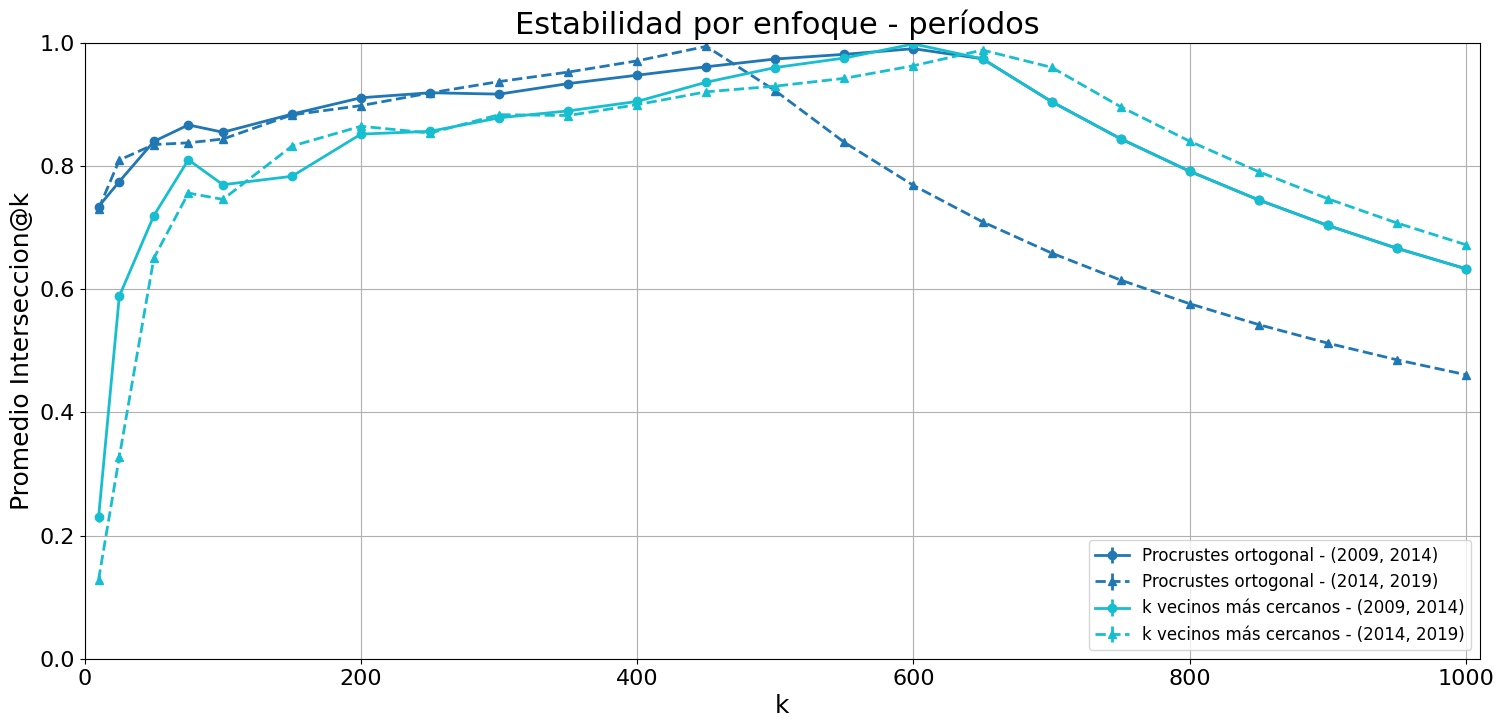

In [14]:
fig = plt.figure(figsize=(18, 8))
line_styles = {'(2009, 2014)': '-o', '(2014, 2019)': '--^'}
unique_labels = sorted(list(set(k for periodo_data in estabilidad_k.values() for k in periodo_data.keys())))
colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios
color_map = {label: colors(i) for i, label in enumerate(unique_labels)}

for i, label in enumerate(unique_labels):
    for par_periodo, dic in estabilidad_k.items():
        if label in dic:
            datos = dic[label]
            X = datos['k']
            Y = datos['promedio interseccion k ']
            yerr = [datos['errores inferiores'], datos['errores superiores']]
            plt.errorbar(X, Y, yerr=yerr, label=f'{label} - {par_periodo}', linewidth=2, fmt=line_styles[par_periodo], color=color_map[label])

plt.gca().tick_params(axis='both', which='major', labelsize=16)
plt.ylim(0, 1)
plt.xlim(0, 1010)
plt.xlabel('k', fontsize=18)
plt.ylabel('Promedio Ιnterseccion@k', fontsize=18)
plt.title('Estabilidad por enfoque - períodos ', fontsize=22)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [15]:
print("Promedio por periodo")
estab_df.groupby(['periodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,periodo,promedio interseccion k
0,"(2009, 2014)",0.829505
1,"(2014, 2019)",0.779882


In [16]:
print("Promedio por periodo")
estab_df.groupby(['metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,metodo,promedio interseccion k
0,Procrustes ortogonal,0.814004
1,k vecinos más cercanos,0.795383


In [18]:
print("Promedio por periodo y método")
estab_df.groupby(['periodo', 'metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo y método


,periodo,metodo,promedio interseccion k
0,"(2009, 2014)",Procrustes ortogonal,0.858580
1,"(2009, 2014)",k vecinos más cercanos,0.800429
3,"(2014, 2019)",k vecinos más cercanos,0.790336
2,"(2014, 2019)",Procrustes ortogonal,0.769427


In [23]:
estab_df.sort_values(by='promedio interseccion k', ascending=False)

,periodo,metodo,k,promedio interseccion k,errores inferiores,errores superiores
37,"(2009, 2014)",k vecinos más cercanos,600,0.998044,0.000064,0.000065
57,"(2014, 2019)",Procrustes ortogonal,450,0.994104,0.000112,0.000112
14,"(2009, 2014)",Procrustes ortogonal,600,0.990344,0.000167,0.000159
84,"(2014, 2019)",k vecinos más cercanos,650,0.988102,0.000143,0.000141
13,"(2009, 2014)",Procrustes ortogonal,550,0.981156,0.000208,0.000206
...,...,...,...,...,...,...
67,"(2014, 2019)",Procrustes ortogonal,950,0.485263,0.000000,0.000000
68,"(2014, 2019)",Procrustes ortogonal,1000,0.461000,NaN,NaN
70,"(2014, 2019)",k vecinos más cercanos,25,0.327543,0.007739,0.007869
23,"(2009, 2014)",k vecinos más cercanos,10,0.229878,0.008000,0.007755



La figura y las tablas de resultados muestran la intersección promedio @k entre los 1225 pares de ejecuciones diferentes para cada enfoque y periodo, con intervalos de confianza del 95 % calculados mediante el método bootstrap. 

Se observa que el método Procrustes ortogonal presenta mayor estabilidad general con errores reducidos, especialmente para k ≤ 300. 

 * La intersección promedio de procruste es 0.81 versus 0.79 de NN. Este valor superior a 0.8 indica un alto valor de solapamiento entre las k palabras más cambiadas identificadas por múltiples ejecuciones del modelo con diferentes inicializaciones aleatorias. 
 * La media de intersección es de 0.86 para 2009–2014 y 0.77 para 2014–2019, frente a valores inferiores y más variables en el método de NN.
 * Procrustes presentó intervalos de confianza estrechos (<0.002), lo que refuerza su confiabilidad para comparaciones diacrónicas de vocabulario legislativo.

Estabilidad por período:
La comparación entre 2009–2014 es más estable que entre 2014–2019 para ambos métodos, lo que podría indicar:
* Un cambio semántico más abrupto o disperso en el segundo período.
* Mayor ruido o complejidad semántica en la producción legislativa 2014–2019 (Pandemia).


Se tomará **k= 300** para evaluar cualitativamente los enfoques y los períodos, al ser el valor de intesección entre los enfoques y tener un 80% de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque.


### Palabras más cambiadas por período de 5 años

In [24]:
#print(all_dfs['NN']['df']['par_periodo'].unique())
#print(all_dfs['procrustes']['df']['par_periodo'].unique())
pares_periodo = [ (2009, 2014),(2014, 2019)]
pares_periodo

[(2009, 2014), (2014, 2019)]

In [25]:
''' para verificar
# Frecuencia de palabras por período
df = all_dfs['NN']['df']
par_periodo = (2009, 2014)
df = df[df['par_periodo'] == str(par_periodo)]
flag = all_dfs['NN']['bandera']
frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
frecPer1.columns = ['palabra', 'frec1', 'porc1']
frecPer2.columns = ['palabra', 'frec2', 'porc2']
df = df[df['par_periodo'] == str(par_periodo)]
df.head(2)
'''

" para verificar\n# Frecuencia de palabras por período\ndf = all_dfs['NN']['df']\npar_periodo = (2009, 2014)\ndf = df[df['par_periodo'] == str(par_periodo)]\nflag = all_dfs['NN']['bandera']\nfrecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')\nfrecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')\nfrecPer1.columns = ['palabra', 'frec1', 'porc1']\nfrecPer2.columns = ['palabra', 'frec2', 'porc2']\ndf = df[df['par_periodo'] == str(par_periodo)]\ndf.head(2)\n"

### Evaluación cualitativa: Palabras con mayor cambio entre pares [2009-2014) y [2014-2019) y [2014-2019) a  [2019-2024)

Evaluamos cualitativamente las 300 palabras con mayor cambio entre los pares de períodos, según cada enfoque. Introducimos un umbral de frecuencia de 5 ocurrencias en al menos uno de los períodos de 5 años para los enfoques que aún no cuentan con umbrales de frecuencia.

* Frecuencia media de las palabras en cada periodo es 5

ojo: El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4.



In [27]:
n = 300
at_least_in_any_decade = 5

csvs = []
topn_periodo_dic = {}
for par_periodo in  [(2009, 2014),(2014, 2019)]:
    
    enfoque_topn = {} 
    for method_name, method_results in all_dfs.items(): 

        print(method_name)
        label = method_results['descripcion']
        df = method_results['df']
        df = df[df['par_periodo']== str(par_periodo)]
        flag = method_results['bandera']

        frecPer1 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
        frecPer2 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
        frecPer1 = frecPer1[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer2 = frecPer2[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer1.columns = ['palabra', 'frec1', 'porc1']
        frecPer2.columns = ['palabra', 'frec2', 'porc2']
        print(frecPer1.shape)
        print(frecPer2.shape)
        print(frecPer1)
    
        df_topn = df.loc[(df.iteracion==0)]
        #controlar frec
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')

        
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn[['palabra','similaridad_semantica','neighbors_t1', 'neighbors_t2']].sort_values('similaridad_semantica', ascending=flag).head(n)
        enfoque_topn[method_name] = df_topn
        
        new_name = method_name.lower().replace(' ', '_')
        new_name = new_name.replace('-', '')
        new_periodo = str(par_periodo)
        new_periodo = new_periodo.replace('(', '')
        new_periodo = new_periodo.replace(')', '')
        new_periodo = new_periodo.replace(',', '_')
        
        csv_path = modelo_dir+'/'+new_name+'_periodo'+str(new_periodo)+'_top'+str(n)+'.csv'
        #csvs.append(csv_path)

        df_topn.to_csv(csv_path, index=False)
        csvs.append(df_topn)

    topn_periodo_dic[par_periodo] = enfoque_topn

procrustes
(1714, 3)
(1969, 3)
             palabra  frec1     porc1
0               paro      1  0.000127
1               ipod      1  0.000127
2               desa      1  0.000127
3     semiautomatico      1  0.000127
4         patagonico      1  0.000127
...              ...    ...       ...
1709          social    109  0.013878
1710        programa    112  0.014260
1711           salud    133  0.016934
1712        creacion    157  0.019990
1713        nacional    208  0.026483

[1714 rows x 3 columns]
NN
(1714, 3)
(1969, 3)
             palabra  frec1     porc1
0               paro      1  0.000127
1               ipod      1  0.000127
2               desa      1  0.000127
3     semiautomatico      1  0.000127
4         patagonico      1  0.000127
...              ...    ...       ...
1709          social    109  0.013878
1710        programa    112  0.014260
1711           salud    133  0.016934
1712        creacion    157  0.019990
1713        nacional    208  0.026483

[1714 ro

(2009, 2014)
Procrustes:  {'materia', 'recurso', 'legal', 'empleo', 'acompanante', 'ingreso', 'tipo', 'declaracion', 'inciso', 'personal'}
NN: {'basica', 'atencion', 'premio', 'acompanante', 'precio', 'ter', 'evaluacion', 'psicologico', 'dengue', 'patologia'}
(2014, 2019)
Procrustes:  {'accesibilidad', 'comunitario', 'pais', 'materia', 'gratuidad', 'dispositivo', 'adecuado', 'forma', 'tipo', 'domiciliario'}
NN: {'comunitario', 'compra', 'gratuidad', 'academia', 'esencial', 'adecuado', 'establecer', 'domiciliario', 'evaluacion', 'fortalecimiento'}


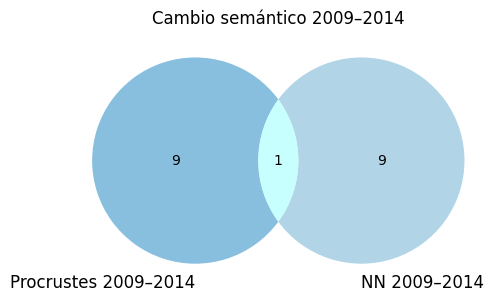

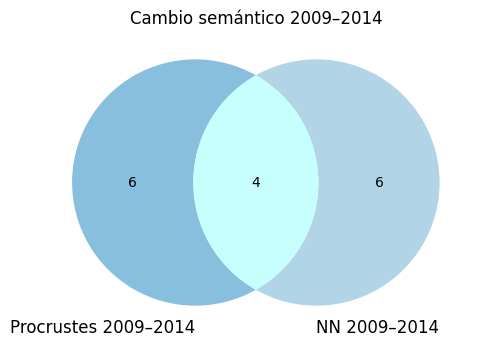

In [32]:
from matplotlib_venn import venn2

K= 10
seman_dic = {}
for periodo, dicTop in topn_periodo_dic.items():
    print(periodo)
    seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[0])] = set(pal[0] for pal in dicTop['procrustes'][['palabra']].head(K).values)
    seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[0])] = set(pal[0] for pal in dicTop['NN'][['palabra']].head(K).values)

    #display(dicTop['procrustes'].head(K))
    print("Procrustes: ",seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[0])])
    print("NN:",seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[0])])
    # Crear la figura
    plt.figure(figsize=(12, 5))
    # Diagrama Venn para 2009–2014
    plt.subplot(1, 2, 1)
    venn2([seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[0])], seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[0])]],
      set_labels=('Procrustes 2009–2014', 'NN 2009–2014'),
      set_colors=('#6baed6', '#9ecae1'), alpha=0.8)
    plt.title('Cambio semántico 2009–2014')
    

* Período: (2009, 2014)
    * Procrustes detecta términos institucionales, jurídicos y administrativos (legal, declaración, inciso, materia, ingreso). 'acompañante' aparece en ambos métodos
    * NN capta conceptos de salud pública (dengue, patología, atención, psicológico).
* Período: (2014, 2019)
    * Ambos métodos coinciden en varias palabras clave: comunitario, gratuidad, domiciliario, adecuado lo que refuerza su confiabilidad y relevancia. 


Los modelos por periodo en base a embeding entrenados en menos de 2000 títulos por período presentan inestabilidad, como se observo en las gráficas anteriores. 
A nivel cualitativo el enfoque Procrustes detecta más verbos,  adjentivos (alto, minimo, complementario, general ) y adverbio (respectivamente) que NN.
El enfoque NN evidencia de manera más directas palabras que uno asociaría al covid 19 (sanitario, decreto, victima) y a temas vinculado con la sexualidad (sexual).

Tanto Procruste y NN  identifican cambios semanticos de determinadas palabras entre el par de períodos:
* [2009, 2014) y [2014, 2019): tipo, educacion, poblacion, territorio y dengue .
* [2014, 2019) y [2019, 2024): sustancia y evaluación.


Los modelos generados en general son inestables al ser entrenados en pocos datos. Pero aún así
* Si buscamos estabilidad y comparabilidad: Orthogonal Procrustes sería la opción.
* Si buscamos una detección simple y efectiva : NN (Nearest Neighbors) es fácil de aplicar.